# From real data to epidemic scenarios

Let us put together what we have learned: select some real data, fit the first days and use the result in a SIR model. Then we will reduce contacts and see what happens when we return to normal.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### 1 - Get the data

We download the [Johns Hopkins time series](https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data/csse_covid_19_time_series) directly with `pd.read_csv`, as in Exploring Real Data. You need an Internet connection. We select Italy, from 24 February to 31 May 2020, keeping cumulative confirmed, recovered and death counts.

For comparison with $I(t)$, calculate **reported active cases**:

$$I_{reported}=confirmed-recovered-deaths.$$

This is only a proxy for infectious people: testing and reporting affect these counts. Cumulative confirmed cases are not $I(t)$.

In [ ]:
base_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/"

confirmed = pd.read_csv(base_url + "time_series_covid19_confirmed_global.csv")
recovered = pd.read_csv(base_url + "time_series_covid19_recovered_global.csv")
deaths = pd.read_csv(base_url + "time_series_covid19_deaths_global.csv")

def country_series(table, country):
    columns = table.columns[table.columns.str.fullmatch(r"\d{1,2}/\d{1,2}/\d{2}")]
    rows = table.loc[table["Country/Region"] == country, columns]
    series = rows.sum(axis=0, min_count=1)
    series.index = pd.to_datetime(series.index, format="%m/%d/%y")
    return series.sort_index()

italy = pd.DataFrame({
    "confirmed": country_series(confirmed, "Italy"),
    "recovered": country_series(recovered, "Italy"),
    "deaths": country_series(deaths, "Italy"),
})

## TO DO: select the date range from 2020-02-24 to 2020-05-31 and set the index name to "date" 
## using the loc method and the copy method
italy = ###
italy.index.name = "date"
italy.head()

            confirmed  recovered  deaths
2020-01-22          0          0       0
2020-01-23          0          0       0
2020-01-24          0          0       0
2020-01-25          0          0       0
2020-01-26          0          0       0


,confirmed,recovered,deaths
date,,,
2020-02-24,229,1,7
2020-02-25,322,1,10
2020-02-26,453,3,12
2020-02-27,655,45,17
2020-02-28,888,46,21


**Your turn:** add `active`, then plot it.

**Hint:** subtract the `recovered` and `deaths` columns from `confirmed`.

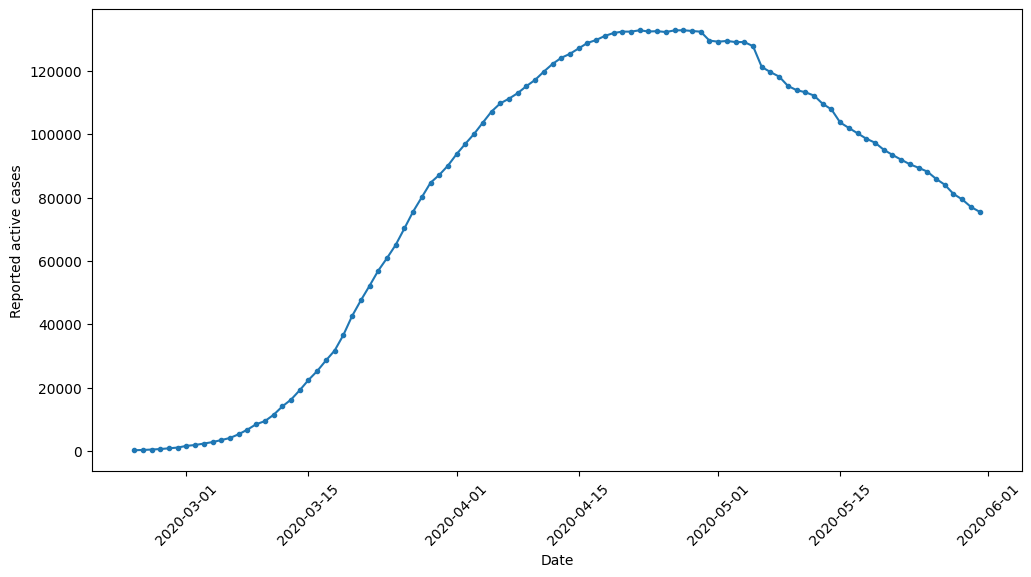

In [ ]:
italy["active"] = None  # TODO: calculate reported active cases

plt.figure(figsize=(12, 6))
# TODO: plot
plt.xlabel("Date"); plt.ylabel("Reported active cases")
plt.xticks(rotation=45);

### 2 - Keep only the first 14 days

We count time from the first observation: day 0 is 24 February. Our fitting window contains days **0 to 13**, including both endpoints. This is a candidate window to explore, not a period guaranteed to have constant transmission.

**Your turn:** select the first `n_days` rows and extract the times and active counts.

**Hint:** use `italy.iloc[:n_days]`, then `early["t_days"].to_numpy()` and the same for `active`.

In [ ]:
italy["t_days"] = (italy.index - italy.index[0]).days
n_days = 14
early = None   # TODO: select the first n_days rows
t_fit = None   # TODO: extract t_days as an array
y_fit = None   # TODO: extract active as an array
# TODO: display early

### 3 - Fit an exponential

At the beginning, $S/N\approx1$, so the SIR equation gives

$$I(t)\approx A e^{rt},\qquad r\approx\beta-\gamma.$$

We fit the initial size $A$ and the growth rate $r$. `curve_fit` finds the parameters that minimize squared differences between observations and model counts.

**Your turn:** complete the exponential function. **Hint:** `np.exp(r*t)`.

In [ ]:
def exponential(t, A, r):
    return None  # TODO

## TODO curve fit 
A, r = parameters
print(f"A = {A:.1f}, r = {r:.3f} per day")
print(f"Doubling time = {np.log(2)/r:.1f} days")

In [ ]:
plt.figure(figsize=(12, 6))
# TODO plot data used for fitting
# TODO plot fit
plt.xlabel("Days since 24 February"); plt.ylabel("Reported active cases")
plt.legend();

Try `n_days = 7` and `10`, rerunning sections 2–3. Is the estimated growth rate the same? Restore **14** before continuing.

### 4 - Use the full SIR model

For this exercise, assume $\gamma=1/10$ per day and $N=60$ million. These are fixed teaching assumptions, not fitted values. Hence $\beta\approx r+\gamma$: the exponential fit alone cannot determine both parameters.

We use the fitted $A$ for $I(0)$ and the first reported recovered + deaths count for $R(0)$; here **R means removed**. We temporarily treat reported counts as model counts, ignoring unreported infections. This is a scenario, not a calibrated forecast.

**Your turn:** complete `beta` and the infected rate. The Euler loop is the same as in our first notebook.

In [ ]:
gamma = 1/10
beta = None  # TODO: use r and gamma
N = 60_000_000
I0 = A
R_initial = float(italy["recovered"].iloc[0] + italy["deaths"].iloc[0])

def SIR(q=1., release=400, T=400, dt=0.01):
    times = np.linspace(0, T, int(T/dt) + 1)
    S = [N - I0 - R_initial]
    I = [I0]
    R = [R_initial]
    for t in times[:-1]:
        # Reduce contacts from day 14 until the release day.
        q_now = None # define q_now as q if t is between 14 and release, otherwise 1
        infections = q_now * beta * S[-1] * I[-1] / N
        recoveries = gamma * I[-1]
        S_change = -infections
        I_change = None  # TODO: infections minus recoveries
        R_change = recoveries
        S.append(S[-1] + dt*S_change)
        I.append(I[-1] + dt*I_change)
        R.append(R[-1] + dt*R_change)
    return times, np.array(S), np.array(I), np.array(R)

times, S, I, R = SIR()
print(f"beta = {beta:.3f}, basic reproduction number = {beta/gamma:.2f}")

Overlay **data, exponential and full SIR** on the same axes. The log scale keeps all three visible when the exponential becomes very large.

In [ ]:
t_data = italy["t_days"].to_numpy()
plt.figure(figsize=(12, 6))
plt.plot(t_data, italy["active"], "o", ms=3, label="Reported active cases")
plt.plot(t_data, exponential(t_data, A, r), "--k", label="Exponential")
visible = times <= t_data[-1]
plt.plot(times[visible], I[visible], lw=2, label="SIR: constant beta")
plt.axvspan(0, n_days-1, alpha=0.15, color="grey", label="Fitting window")
plt.yscale("log"); plt.xlim(0, t_data[-1])
plt.xlabel("Days since 24 February"); plt.ylabel("Active / infected people (log scale)")
plt.legend();

*Why are the two model curves close at first? Why does the SIR eventually bend? Does adding susceptible depletion make it fit the observed epidemic?*

### 5 - Add mitigation, then reopen

We now multiply $\beta$ by $q$: `q = 1` means normal contacts, `q = 0.25` means transmission is reduced to 25%. Mitigation starts on day 14; `release` is the day we restore `q = 1`.

**Your turn:** compare reopening on days 60 and 120. **Hint:** call `SIR(q=0.25, release=release)` inside the loop. These are hypothetical scenarios, not a fit of the actual restrictions.

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(times, I/N, "--k", label="No mitigation")
for release in [60, 120]:
    tm, Sm, Im, Rm = None  # TODO: run SIR with mitigation
    plt.plot(tm, Im/N, lw=2, label=f"Reopen on day {release}")
    plt.axvline(release, color="grey", alpha=0.3)
plt.xlabel("Days since 24 February"); plt.ylabel("Infected fraction I/N")
plt.legend();

*Does a later reopening prevent a second wave, or mainly postpone it? Why can cases fall during mitigation and rise again afterwards?*

### 6 - Ex: When can we return to normal in this model?

For $I>0$, after full reopening,

$$\frac{dI}{dt}\leq0\quad\Longleftrightarrow\quad R_{eff}=\frac{\beta S}{\gamma N}\leq1.$$

**Your turn:** calculate $R_{eff}$ at each release day. Does either scenario satisfy the condition? Use the susceptible count **at reopening**, not at the end of the simulation.


In [ ]:
for release in [60, 120]:
    tm, Sm, Im, Rm = SIR(q=0.25, release=release)
    k = np.argmin(abs(tm-release))
    Reff = None  # TODO: beta*S/(gamma*N) at reopening
    print(f"Day {release}: R_eff = {Reff:.2f}, no renewed growth? {Reff <= 1}")

If full reopening fails this condition, what fraction of normal transmission could we allow? Solve $q\beta S/(\gamma N)\leq1$ for $q$.

*Write your answer here. Would looking only at a small number of active cases be enough?*

This is a condition within our closed, deterministic SIR model, not a real-world reopening rule. It omits vaccination, new arrivals, changing immunity and uncertainty in reporting.